# ¿Cuánto vale tu trabajo?
## Análisis exploratorio del salario mínimo y la desigualdad en Europa

### Contexto del proyecto

Este proyecto analiza la evolución del salario mínimo en Europa y su relación con indicadores clave de desigualdad: poder adquisitivo, brecha de género, acceso a la vivienda, pobreza laboral e inflación.

El análisis no se limita a la UE27. Incluye 38 países europeos (27 de la UE + 11 vecinos: Noruega, Suiza, Islandia, Reino Unido, Serbia, Turquía, Montenegro, Macedonia del Norte, Albania, Bosnia y Moldavia). La UE27 no existe en el vacío: comparar con vecinos revela si el proyecto europeo protege a sus trabajadores o si el bienestar trasciende la pertenencia a la UE.

**Fuente de datos:** Eurostat (8 datasets: 5 descargados en TSV + 3 vía API pública).

**Dataset final:** 1016 filas × 12 columnas, 38 países, periodo 1999-2026. Generado en el Notebook 1 (limpieza y merge).

### Las 5 hipótesis

| # | Hipótesis | Pregunta | Variables principales |
|---|-----------|----------|----------------------|
| H1 | El salario nominal engaña | ¿El salario en EUR refleja el nivel de vida real? | salario_min_eur vs salario_min_pps |
| H2 | El salario mínimo como herramienta feminista | ¿Mayor salario mínimo = menor brecha de género? | salario_min_pps vs brecha_genero |
| H3 | El salario mínimo no da para vivir | ¿La vivienda sube más rápido que el salario? | salario_min_pps vs indice_vivienda |
| H4 | Trabajar no te saca de pobre | ¿Un salario bajo se asocia a más pobreza laboral? | salario_min_pps vs pobreza_laboral |
| H5 | La Gen Z trabaja más para vivir peor | ¿La inflación se ha comido el salario real? | salario_min_eur vs inflacion_hicp |

### Metodología de validación

Cada hipótesis se valida con el **test de correlación de Pearson** (scipy.stats.pearsonr). Una hipótesis se considera estadísticamente significativa si el p-value es inferior a 0.05 (menos del 5% de probabilidad de que el resultado sea casualidad). En hipótesis donde la pregunta no es de correlación lineal (como H3, donde pregunto por velocidad de crecimiento), complemento el test con análisis de crecimiento relativo.

### Nota sobre visualizaciones

Todos los gráficos de este notebook usan **Plotly Express** (plotly.express), que genera gráficos interactivos: al pasar el ratón sobre cualquier punto o barra se muestran los datos detallados.

In [2]:
# ============================================================
# NOTEBOOK 2: ANÁLISIS DE HIPÓTESIS
# ============================================================
# Este notebook parte del dataset limpio que generé en el Notebook 1.
# Aquí cargo el CSV final y analizo las 5 hipótesis del proyecto,
# usando visualizaciones y tests estadísticos para validarlas.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # Contiene la función pearsonr para medir correlaciones
import plotly.express as px   # Para gráficos interactivos (pasar el ratón = ver datos)

# Las gráficas aparecen directamente en el notebook
%matplotlib inline

# Estilo visual: fondo blanco con rejilla suave
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Desactivo warnings para que el output esté limpio
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [3]:
# ============================================================
# CARGAR EL DATASET LIMPIO DEL NOTEBOOK 1
# ============================================================
# En el Notebook 1 limpié y mergée 8 datasets de Eurostat y
# guardé el resultado en dataset_europa_final.csv.
# Aquí lo cargo directamente para no repetir todo ese proceso.
# pd.read_csv() lee un archivo CSV y lo convierte en DataFrame.
# ============================================================

df = pd.read_csv('./data/dataset_europa_final.csv')

print(f"Dataset cargado: {len(df)} filas × {len(df.columns)} columnas")
print(f"Columnas: {df.columns.tolist()}")
print(f"Rango temporal: {df['anio'].min()} - {df['anio'].max()}")
print(f"Países: {df['geo'].nunique()}")

Dataset cargado: 1016 filas × 12 columnas
Columnas: ['geo', 'anio', 'salario_min_eur', 'salario_min_pps', 'pib_pps', 'indice_vivienda', 'gini', 'brecha_genero', 'pobreza_laboral', 'tasa_desempleo', 'inflacion_hicp', 'es_eu27']
Rango temporal: 1999 - 2026
Países: 38


In [4]:
# ============================================================
# EXPLORACIÓN RÁPIDA
# ============================================================
# Cada vez que cargo un CSV en un notebook nuevo, lo primero
# es verificar que los tipos de datos son correctos.
# Si 'anio' se cargó como texto en vez de número, me reventaría
# una gráfica más adelante. Mejor pillarlo aquí.
# ============================================================

print("Tipos de datos:")
print(df.dtypes)
print(f"\nPrimeras filas:")
df.head(35)

Tipos de datos:
geo                    str
anio                 int64
salario_min_eur    float64
salario_min_pps    float64
pib_pps            float64
indice_vivienda    float64
gini               float64
brecha_genero      float64
pobreza_laboral    float64
tasa_desempleo     float64
inflacion_hicp     float64
es_eu27               bool
dtype: object

Primeras filas:


,geo,anio,salario_min_eur,salario_min_pps,pib_pps,indice_vivienda,gini,brecha_genero,pobreza_laboral,tasa_desempleo,inflacion_hicp,es_eu27
0,AL,1999,45.0,89.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,AL,2000,49.5,99.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,AL,2001,56.5,107.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,AL,2002,65.5,123.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,AL,2003,70.5,143.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
5,AL,2004,81.5,154.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
6,AL,2005,90.0,168.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
7,AL,2006,105.0,189.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
8,AL,2007,114.0,204.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
9,AL,2008,135.0,237.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [5]:
# ============================================================
# RESUMEN ESTADÍSTICO
# ============================================================
# .describe() es como un chequeo médico del dataset.
# Para cada columna numérica calcula:
#   count = cuántos valores NO son NaN (me dice cuántos datos tengo)
#   mean  = la media (promedio)
#   std   = desviación estándar (cuánto se dispersan los datos)
#   min   = valor mínimo
#   25%   = primer cuartil (el 25% de los datos están por debajo)
#   50%   = mediana (el valor del medio, más robusto que la media)
#   75%   = tercer cuartil
#   max   = valor máximo
#
# Si veo algo raro (un salario negativo, un Gini de 200), sé que
# hay un error de limpieza que tengo que arreglar.
# ============================================================

df.describe().round(2)

,anio,salario_min_eur,salario_min_pps,pib_pps,indice_vivienda,gini,brecha_genero,pobreza_laboral,tasa_desempleo,inflacion_hicp
count,1016.00,728.00,697.00,424.00,278.00,303.00,495.00,704.00,583.00,914.00
mean,2012.69,689.88,773.87,96.63,146.28,30.23,14.33,8.16,8.81,99.21
std,7.96,558.23,422.70,47.08,48.66,4.66,6.25,3.17,5.28,53.85
min,1999.00,2.00,29.00,29.00,74.32,20.90,-2.20,2.50,2.00,8.58
25%,2006.00,254.88,439.00,67.00,110.56,27.00,9.60,5.80,5.20,83.12
50%,2013.00,522.50,723.00,88.00,135.31,29.80,15.00,7.70,7.30,99.10
75%,2020.00,1051.00,1078.00,121.00,170.70,32.85,18.55,10.10,10.60,105.07
max,2026.00,2704.00,2157.00,280.00,347.43,45.30,30.90,19.70,32.20,1221.20


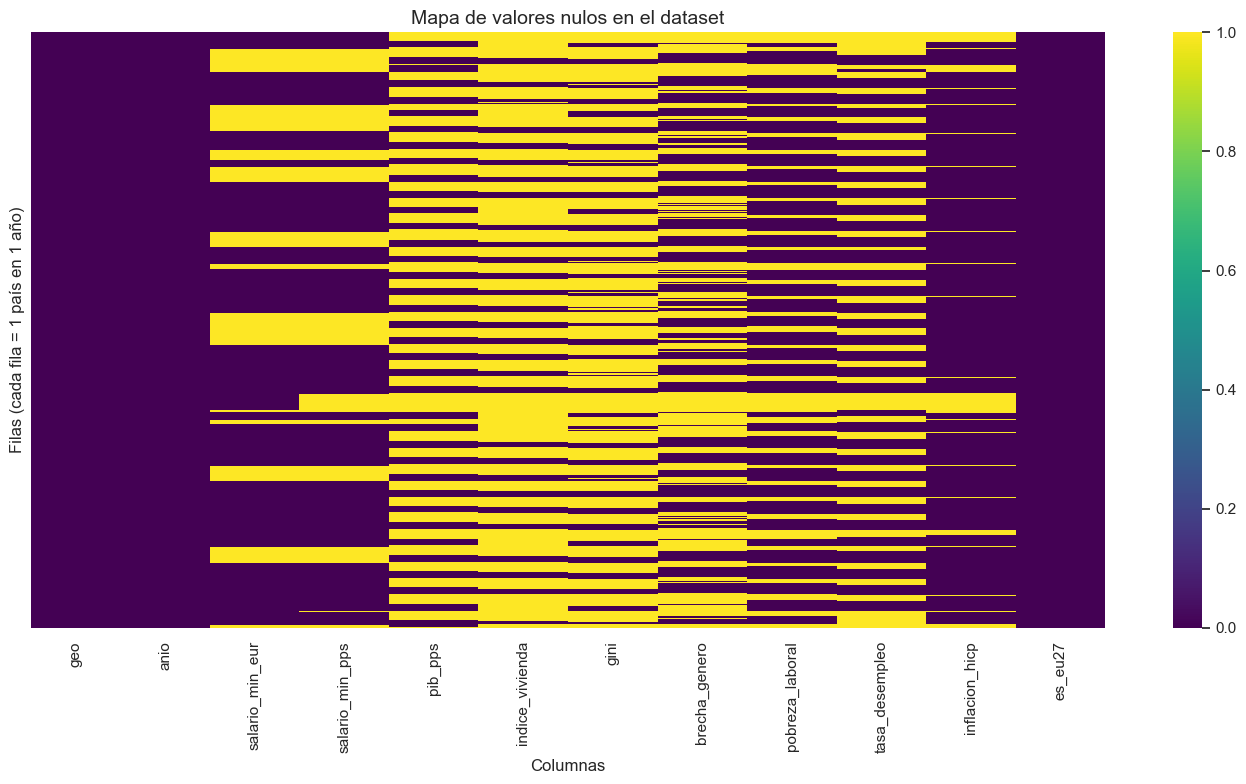


Nulos por columna:
                 nulos  % del total
indice_vivienda    738         72.6
gini               713         70.2
pib_pps            592         58.3
brecha_genero      521         51.3
tasa_desempleo     433         42.6
salario_min_pps    319         31.4
pobreza_laboral    312         30.7
salario_min_eur    288         28.3
inflacion_hicp     102         10.0


In [6]:
# ============================================================
# VISUALIZACIÓN DE NULOS
# ============================================================
# Un heatmap (mapa de calor) me permite ver de un vistazo dónde
# están los huecos en mis datos.
#
# ¿Qué es un heatmap?
# Es una tabla donde cada celda tiene un color en vez de un número.
# Aquí: amarillo = hay dato, morado = falta dato (NaN).
#
# ¿Por qué me importan los nulos?
# Porque cada hipótesis usa columnas distintas. Si la columna
# 'brecha_genero' tiene un 50% de NaN, solo puedo analizar H2
# con la mitad de los datos. Necesito saber esto ANTES de empezar.
#
# sns.heatmap() dibuja el mapa de calor
# df.isnull() convierte cada celda en True (NaN) o False (tiene dato)
# cmap='viridis' es la paleta de colores (amarillo-verde-morado)
# yticklabels=False quita las etiquetas del eje Y (con 1016 filas
# serían ilegibles y ralentizarían el notebook)
# ============================================================

plt.figure(figsize=(14, 8))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Mapa de valores nulos en el dataset', fontsize=14)
plt.xlabel('Columnas')
plt.ylabel('Filas (cada fila = 1 país en 1 año)')
plt.tight_layout()
plt.show()

# Resumen numérico: el gráfico es para presentar, las cifras para ser preciso
print("\nNulos por columna:")
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(1)
resumen_nulos = pd.DataFrame({'nulos': nulos, '% del total': pct_nulos})
print(resumen_nulos[resumen_nulos['nulos'] > 0].sort_values('% del total', ascending=False))

In [7]:
# ============================================================
# CONFIGURACIÓN PARA EL ANÁLISIS
# ============================================================
# Defino las listas de países (las mismas del Notebook 1) y una
# función reutilizable para el test de Pearson.
#
# ¿Qué es una función?
# Es un bloque de código con nombre que puedo llamar cuando quiera.
# En vez de escribir las mismas 15 líneas cada vez que quiero
# hacer un test de Pearson, las escribo UNA vez dentro de la
# función y luego la llamo con una sola línea.
# Es como crear mi propia herramienta dentro de Python.
#
# La sintaxis es:
#   def nombre_funcion(parametros):
#       ...código...
#       return resultado
#
# Y la llamo así:
#   resultado = nombre_funcion(mis_datos)
# ============================================================

eu27 = ['AT','BE','BG','CY','CZ','DE','DK','EE','EL','ES',
        'FI','FR','HR','HU','IE','IT','LT','LU','LV','MT',
        'NL','PL','PT','RO','SE','SI','SK']

extra_europeos = ['NO','CH','IS','UK','RS','TR','ME','MK','AL','BA','MD']

paises_europa = eu27 + extra_europeos


def test_pearson(df_input, col_x, col_y, nombre_test=""):
    """
    Realiza el test de correlación de Pearson entre dos columnas.
    
    Recibe:
    - df_input: el DataFrame con los datos
    - col_x: nombre de la primera columna (ej: 'salario_min_eur')
    - col_y: nombre de la segunda columna (ej: 'gini')
    - nombre_test: un texto descriptivo para identificar el resultado
    
    Devuelve: (r, p_value)
    - r: coeficiente de correlación (-1 a +1)
    - p_value: probabilidad de que sea casualidad (si < 0.05, es significativa)
    """
    # dropna() elimina las filas donde alguna de las dos columnas es NaN.
    # Pearson necesita que AMBOS valores existan en cada fila.
    # Si un país tiene salario pero no Gini, esa fila no puede participar.
    datos = df_input[[col_x, col_y]].dropna()
    
    # Protección: si quedan menos de 3 filas, Pearson no tiene sentido
    if len(datos) < 3:
        print(f"  {nombre_test}: datos insuficientes ({len(datos)} filas)")
        return None, None
    
    # stats.pearsonr() es la función de SciPy que hace el cálculo
    # Devuelve dos valores: r (correlación) y p_value
    corr, p_value = stats.pearsonr(datos[col_x], datos[col_y])
    
    # Interpreto la fuerza de la correlación
    abs_corr = abs(corr)
    if abs_corr < 0.3:
        fuerza = "débil"
    elif abs_corr < 0.5:
        fuerza = "moderada"
    elif abs_corr < 0.7:
        fuerza = "notable"
    else:
        fuerza = "fuerte"
    
    direccion = "positiva" if corr > 0 else "negativa"
    significativa = "SÍ" if p_value < 0.05 else "NO"
    
    print(f"  {nombre_test}")
    print(f"    Observaciones válidas: {len(datos)}")
    print(f"    Correlación (r): {corr:.4f} ({fuerza}, {direccion})")
    print(f"    P-value: {p_value:.6f}")
    print(f"    ¿Significativa (p < 0.05)?: {significativa}")
    print()
    
    return corr, p_value


print(f"EU27: {len(eu27)} países")
print(f"Europa total: {len(paises_europa)} países")
print("Función test_pearson() definida")

EU27: 27 países
Europa total: 38 países
Función test_pearson() definida


## H1: El salario nominal engaña

**Hipótesis:** El salario mínimo en euros no refleja el nivel de vida real. Dos países pueden tener el mismo salario nominal pero capacidades de compra muy diferentes. El ajuste por Poder de Paridad de Compra (PPS) revela las diferencias reales.

**¿Qué es PPS?** Purchasing Power Standard. Es una moneda artificial que ajusta los precios entre países. Si un café cuesta 1€ en España pero 3€ en Noruega, ganar 1000€ en España equivale a más poder de compra que 1000€ en Noruega. PPS corrige eso.

**Columnas que uso:** `salario_min_eur` (nominal, en euros) y `salario_min_pps` (ajustado por poder adquisitivo)

**¿Cómo la valido?** Si los rankings de países cambian significativamente al pasar de EUR a PPS, la hipótesis se confirma: el salario nominal engaña.

In [8]:
# ============================================================
# H1: PREPARAR LOS DATOS
# ============================================================
# Para comparar salario nominal vs PPS necesito un año concreto
# donde haya datos de ambas columnas para el máximo de países.
#
# ¿Por qué un año concreto?
# Porque quiero hacer un ranking de países. Si mezclo todos los
# años, cada país aparecería muchas veces y el ranking no tendría
# sentido. Elijo el año más reciente con datos completos.
#
# Primero miro qué años tienen más datos disponibles.
# ============================================================

# Filtro solo filas donde tengo AMBOS salarios (EUR y PPS)
df_h1 = df[['geo', 'anio', 'salario_min_eur', 'salario_min_pps', 'es_eu27']].dropna()

print("Filas con ambos salarios disponibles:")
print(f"  Total: {len(df_h1)}")
print(f"\nDatos por año:")
print(df_h1.groupby('anio')['geo'].nunique().to_string())
print(f"\n¿Qué año tiene más países? Elijo el más reciente con buena cobertura.")

Filas con ambos salarios disponibles:
  Total: 697

Datos por año:
anio
1999    21
2000    23
2001    23
2002    23
2003    23
2004    23
2005    23
2006    23
2007    23
2008    24
2009    24
2010    24
2011    24
2012    24
2013    26
2014    26
2015    27
2016    27
2017    27
2018    27
2019    27
2020    27
2021    26
2022    26
2023    27
2024    27
2025    26
2026    26

¿Qué año tiene más países? Elijo el más reciente con buena cobertura.


In [9]:
# ============================================================
# H1: RANKINGS EUR vs PPS
# ============================================================
# Elijo 2024 como año de referencia (el más reciente con datos).
# Creo dos rankings: uno por salario en euros y otro por salario
# en PPS. Si las posiciones cambian mucho, H1 se confirma.
#
# .sort_values() ordena el DataFrame por una columna
# .rank(ascending=False) asigna posiciones: el valor más alto = 1
# ============================================================

anio_ref = 2024
df_ranking = df_h1[df_h1['anio'] == anio_ref].copy()

# Creo las columnas de ranking
# ascending=False = el salario más ALTO recibe la posición 1
df_ranking['rank_eur'] = df_ranking['salario_min_eur'].rank(ascending=False).astype(int)
df_ranking['rank_pps'] = df_ranking['salario_min_pps'].rank(ascending=False).astype(int)

# Calculo cuántas posiciones cambia cada país al ajustar por PPS
# Un cambio positivo = sube posiciones al ajustar (vive mejor de lo que parece)
# Un cambio negativo = baja posiciones al ajustar (vive peor de lo que parece)
df_ranking['cambio_posicion'] = df_ranking['rank_eur'] - df_ranking['rank_pps']

# Ordeno por salario nominal para ver el ranking EUR
df_ranking = df_ranking.sort_values('rank_eur')

print(f"Rankings de salario mínimo en {anio_ref}")
print(f"Países con datos: {len(df_ranking)}")
print()
print(df_ranking[['geo', 'salario_min_eur', 'rank_eur', 'salario_min_pps', 'rank_pps', 'cambio_posicion']].to_string(index=False))

Rankings de salario mínimo en 2024
Países con datos: 27

geo  salario_min_eur  rank_eur  salario_min_pps  rank_pps  cambio_posicion
 LU           2571.0         1           1935.0         1                0
 IE           2146.0         2           1554.0         6               -4
 NL           2102.0         3           1812.5         3                0
 DE           2054.0         4           1891.0         2                2
 BE           2032.0         5           1743.5         4                1
 FR           1767.0         6           1589.0         5                1
 ES           1323.0         7           1456.0         7                0
 SI           1254.0         8           1390.0         8                0
 CY           1000.0         9           1078.0        15               -6
 PL            988.0        10           1373.0         9                1
 PT            957.0        11           1100.0        13               -2
 EL            939.0        12           10

In [10]:
# ============================================================
# H1: VISUALIZACIÓN - Salario EUR vs PPS lado a lado
# ============================================================
# plotly.express (px) es la versión "fácil" de Plotly.
# px.bar() crea un gráfico de barras interactivo automáticamente.
#
# El truco aquí es que Plotly necesita los datos en formato "long"
# para dibujar barras agrupadas. Es decir, en vez de tener:
#   geo | salario_min_eur | salario_min_pps
#   ES  | 1323            | 1400
#
# Necesita:
#   geo | tipo    | valor
#   ES  | EUR     | 1323
#   ES  | PPS     | 1400
#
# pd.melt() hace exactamente esa transformación (la misma que
# usé en el Notebook 1 para los datasets de Eurostat).
# ============================================================

# Preparo los datos en formato long para Plotly
df_barras = df_ranking[['geo', 'salario_min_eur', 'salario_min_pps']].melt(
    id_vars='geo',
    value_vars=['salario_min_eur', 'salario_min_pps'],
    var_name='tipo',
    value_name='salario'
)

# Renombro los valores para que se lean bien en la leyenda
df_barras['tipo'] = df_barras['tipo'].replace({
    'salario_min_eur': 'EUR (nominal)',
    'salario_min_pps': 'PPS (poder adquisitivo)'
})

fig = px.bar(
    df_barras,
    x='salario',               # eje horizontal: el valor del salario
    y='geo',                    # eje vertical: el país
    color='tipo',               # una barra de cada color por tipo
    orientation='h',            # horizontal (los países se leen mejor)
    barmode='group',            # las barras lado a lado, no apiladas
    title=f'H1: Salario mínimo nominal (EUR) vs real (PPS) - {anio_ref}',
    labels={'salario': 'Salario mínimo mensual', 'geo': 'País', 'tipo': 'Medida'},
    color_discrete_sequence=['#2196F3', '#FF5722']
)

# Ordeno los países por salario EUR de mayor a menor
orden_paises = df_ranking.sort_values('salario_min_eur', ascending=True)['geo'].tolist()
fig.update_yaxes(categoryorder='array', categoryarray=orden_paises)

fig.update_layout(height=700)
fig.show()

In [11]:
# ============================================================
# H1: ¿QUIÉN SUBE Y QUIÉN BAJA AL AJUSTAR POR PPS?
# ============================================================
# Barras horizontales con el cambio de posición de cada país.
# Verde a la derecha = sube (vive mejor de lo que parece).
# Rojo a la izquierda = baja (vive peor de lo que parece).
#
# Plotly me permite crear colores condicionales con np.where():
# np.where(condición, valor_si_true, valor_si_false)
# ============================================================

# Ordeno por cambio de posición
datos_cambio = df_ranking.sort_values('cambio_posicion', ascending=True).copy()

# Creo una columna de texto para el tooltip (lo que aparece al pasar el ratón)
datos_cambio['texto'] = datos_cambio.apply(
    lambda fila: f"EUR: {fila['salario_min_eur']:.0f}€ | PPS: {fila['salario_min_pps']:.0f} | "
                 f"Rank EUR: {fila['rank_eur']} → Rank PPS: {fila['rank_pps']}", 
    axis=1
)

# Color condicional: verde si sube, rojo si baja
datos_cambio['color'] = np.where(datos_cambio['cambio_posicion'] > 0, 'Sube (vive mejor)', 
                         np.where(datos_cambio['cambio_posicion'] < 0, 'Baja (vive peor)', 'Sin cambio'))

fig = px.bar(
    datos_cambio,
    x='cambio_posicion',
    y='geo',
    color='color',
    orientation='h',
    title=f'H1: Cambio en el ranking al ajustar por poder adquisitivo ({anio_ref})',
    labels={'cambio_posicion': 'Cambio de posiciones (EUR → PPS)', 'geo': 'País'},
    hover_data={'texto': True, 'cambio_posicion': True, 'color': False},
    color_discrete_map={
        'Sube (vive mejor)': '#4CAF50',
        'Baja (vive peor)': '#F44336',
        'Sin cambio': '#9E9E9E'
    }
)

fig.update_layout(height=700)
fig.show()

# Resumen numérico
print("Top 5 países que MÁS SUBEN al ajustar por PPS:")
top_suben = df_ranking.nlargest(5, 'cambio_posicion')[['geo', 'salario_min_eur', 'salario_min_pps', 'cambio_posicion']]
print(top_suben.to_string(index=False))

print("\nTop 5 países que MÁS BAJAN al ajustar por PPS:")
top_bajan = df_ranking.nsmallest(5, 'cambio_posicion')[['geo', 'salario_min_eur', 'salario_min_pps', 'cambio_posicion']]
print(top_bajan.to_string(index=False))

Top 5 países que MÁS SUBEN al ajustar por PPS:
geo  salario_min_eur  salario_min_pps  cambio_posicion
 RO            703.0           1105.0                8
 MK            513.0            936.0                7
 TR            590.5           1062.0                6
 LT            924.0           1132.0                4
 HR            840.0           1102.0                3

Top 5 países que MÁS BAJAN al ajustar por PPS:
geo  salario_min_eur  salario_min_pps  cambio_posicion
 EE            820.0            820.0               -8
 CY           1000.0           1078.0               -6
 CZ            759.5            851.0               -5
 IE           2146.0           1554.0               -4
 MT            925.0           1010.0               -4


In [12]:
# ============================================================
# H1: SCATTER PLOT - ¿Cómo se relacionan EUR y PPS?
# ============================================================
# Cada punto es un país. Eje X = salario EUR, eje Y = salario PPS.
#
# Si EUR y PPS fueran idénticos, todos los puntos estarían en la
# diagonal (la línea roja punteada que añado como referencia).
# Los puntos por ENCIMA de la diagonal: PPS > EUR (más poder
# adquisitivo del que sugiere el salario nominal).
# Los puntos por DEBAJO: PPS < EUR (menos poder adquisitivo).
#
# px.scatter() crea el gráfico de dispersión.
# text='geo' pone el nombre del país al lado de cada punto.
# ============================================================

fig = px.scatter(
    df_ranking,
    x='salario_min_eur',
    y='salario_min_pps',
    text='geo',                 # Etiqueta con el código de país
    color='es_eu27',            # Color diferente para EU27 vs extra
    title=f'H1: Salario nominal vs poder adquisitivo real ({anio_ref})',
    labels={
        'salario_min_eur': 'Salario mínimo EUR (nominal)',
        'salario_min_pps': 'Salario mínimo PPS (poder adquisitivo)',
        'es_eu27': '¿EU27?'
    },
    hover_data={
        'geo': True,
        'salario_min_eur': ':.0f',
        'salario_min_pps': ':.0f',
        'cambio_posicion': True
    },
    color_discrete_map={True: '#2196F3', False: '#FF9800'}
)

# Muevo las etiquetas un poco arriba para que no tapen el punto
fig.update_traces(textposition='top center', textfont_size=9)

# Línea diagonal de referencia: PPS = EUR
limite = max(df_ranking['salario_min_eur'].max(), df_ranking['salario_min_pps'].max()) + 100
fig.add_shape(
    type='line',
    x0=0, y0=0, x1=limite, y1=limite,
    line=dict(color='red', dash='dash', width=1)
)

fig.update_layout(height=650, width=800)
fig.show()

In [13]:
# ============================================================
# H1: VALIDACIÓN ESTADÍSTICA
# ============================================================
# Aquí aplico el test de Pearson para medir la correlación entre
# el salario nominal (EUR) y el ajustado (PPS).
#
# ¿Qué espero encontrar?
# Una correlación alta y positiva (r cercano a 1): lógico, porque
# ambas son medidas de salario. PERO si r no es 1.0 perfecto,
# significa que el ajuste PPS SÍ cambia las cosas, confirmando H1.
#
# También calculo estadísticas descriptivas del cambio de posición
# para cuantificar cuánto "engaña" el salario nominal.
# ============================================================

print("=" * 60)
print("H1: VALIDACIÓN ESTADÍSTICA")
print("=" * 60)
print()

# Test de Pearson entre EUR y PPS
test_pearson(df_ranking, 'salario_min_eur', 'salario_min_pps', 
             'Correlación EUR vs PPS')

# Estadísticas del cambio de posición
cambios = df_ranking['cambio_posicion']
print(f"Estadísticas del cambio de posición en el ranking:")
print(f"  Media de cambio: {cambios.mean():.1f} posiciones")
print(f"  Cambio máximo hacia arriba: +{cambios.max()} posiciones")
print(f"  Cambio máximo hacia abajo: {cambios.min()} posiciones")
print(f"  Países que cambian de posición: {(cambios != 0).sum()} de {len(cambios)}")
print(f"  Países que NO cambian: {(cambios == 0).sum()} de {len(cambios)}")

H1: VALIDACIÓN ESTADÍSTICA

  Correlación EUR vs PPS
    Observaciones válidas: 27
    Correlación (r): 0.9450 (fuerte, positiva)
    P-value: 0.000000
    ¿Significativa (p < 0.05)?: SÍ

Estadísticas del cambio de posición en el ranking:
  Media de cambio: 0.0 posiciones
  Cambio máximo hacia arriba: +8 posiciones
  Cambio máximo hacia abajo: -8 posiciones
  Países que cambian de posición: 21 de 27
  Países que NO cambian: 6 de 27


### Conclusión H1: El salario nominal engaña

**La hipótesis se valida.**

El test de Pearson muestra una correlación fuerte y positiva (r = 0.945, p < 0.001) entre el salario en euros y el ajustado por poder adquisitivo. Esto es lógico: ambas miden salario. Pero la correlación NO es perfecta (no es 1.0), lo que confirma que el ajuste PPS sí cambia las cosas.

La prueba más contundente está en los rankings: **21 de los 27 países cambian de posición** al ajustar por poder adquisitivo. El cambio llega hasta 8 posiciones en ambas direcciones.

Los casos más llamativos:

- **Rumanía sube 8 posiciones** (de la 19 a la 11): su salario nominal de 703€ parece bajo, pero el coste de vida es tan barato que equivale a 1.105 PPS, más que Portugal o Grecia. Un trabajador rumano puede comprar más con su salario mínimo que un portugués.
- **Estonia baja 8 posiciones** (de la 16 a la 24): cobra 820€ pero su poder adquisitivo real es exactamente 820 PPS, lo que la hunde en el ranking cuando otros países suben.
- **Irlanda baja 4 posiciones** (de la 2 a la 6): el segundo salario más alto de Europa en euros (2.146€), pero Irlanda es tan cara que su poder de compra real cae al puesto 6.
- **Macedonia del Norte sube 7 posiciones** y **Turquía sube 6**: países con salarios bajos en euros pero donde la vida es significativamente más barata.

**Conclusión para la presentación:** comparar salarios mínimos en euros entre países europeos es engañoso. Un mileurista en Bucarest puede tener más capacidad de compra que uno en Dublín. Para entender cuánto vale realmente un salario, hay que ajustar por el coste de vida local.

## H2: El salario mínimo como herramienta feminista

**Hipótesis:** Los países con salario mínimo más alto tienen una brecha de género salarial más pequeña. Es decir, el salario mínimo actúa como herramienta de igualdad porque establece un suelo que beneficia desproporcionadamente a las mujeres (que están sobrerrepresentadas en los empleos peor pagados).

**¿Qué es la brecha de género salarial?** Es la diferencia porcentual entre lo que cobran los hombres y lo que cobran las mujeres. Si la brecha es del 15%, significa que las mujeres cobran de media un 15% menos que los hombres. Una brecha del 0% sería igualdad perfecta.

**Columnas que uso:** `salario_min_pps` (uso PPS y no EUR porque, como demostré en H1, el nominal engaña) y `brecha_genero`

**¿Cómo la valido?** Si hay una correlación negativa significativa (r negativo, p < 0.05) entre salario mínimo y brecha de género, se confirma: a mayor salario mínimo, menor brecha.

In [14]:
# ============================================================
# H2: PREPARAR LOS DATOS
# ============================================================
# Necesito filas donde tenga AMBOS datos: salario mínimo Y brecha
# de género. Voy a trabajar con el año más reciente que tenga
# buena cobertura, igual que en H1.
#
# Uso salario_min_pps (no EUR) porque en H1 demostré que el
# nominal engaña. Sería incoherente usar EUR después de eso.
# ============================================================

df_h2 = df[['geo', 'anio', 'salario_min_pps', 'brecha_genero', 'es_eu27']].dropna()

print(f"Filas con salario PPS y brecha de género: {len(df_h2)}")
print(f"\nDatos por año:")
print(df_h2.groupby('anio')['geo'].nunique().to_string())

Filas con salario PPS y brecha de género: 344

Datos por año:
anio
2002    13
2006    21
2007    19
2008    18
2009    18
2010    19
2011    19
2012    19
2013    20
2014    25
2015    17
2016    18
2017    17
2018    23
2019    19
2020    19
2021    19
2022    19
2023     1
2024     1


In [15]:
# ============================================================
# H2: SCATTER PLOT - ¿Mayor salario = menor brecha?
# ============================================================
# Cada punto es un país en un año concreto.
# Eje X = salario mínimo en PPS
# Eje Y = brecha de género (%)
#
# Si H2 es correcta, los puntos deberían ir "hacia abajo":
# cuanto más a la derecha (más salario), más abajo (menos brecha).
#
# Uso TODOS los años disponibles (no solo 2024) para tener más
# observaciones y que el test de Pearson sea más robusto.
# Con un solo año tendría ~20 puntos; con todos tengo muchos más.
#
# px.scatter() con trendline='ols' añade una línea de tendencia.
# OLS = Ordinary Least Squares, es el método más básico para
# dibujar la "mejor recta" que pasa entre los puntos.
# Si la recta baja de izquierda a derecha = correlación negativa.
# ============================================================

fig = px.scatter(
    df_h2,
    x='salario_min_pps',
    y='brecha_genero',
    color='es_eu27',
    hover_data={'geo': True, 'anio': True, 'salario_min_pps': ':.0f', 'brecha_genero': ':.1f'},
    title='H2: ¿Mayor salario mínimo = menor brecha de género?',
    labels={
        'salario_min_pps': 'Salario mínimo (PPS)',
        'brecha_genero': 'Brecha de género (%)',
        'es_eu27': '¿EU27?'
    },
    trendline='ols',
    color_discrete_map={True: '#2196F3', False: '#FF9800'}
)

fig.update_layout(height=600)
fig.show()

In [16]:
# ============================================================
# H2: EVOLUCIÓN TEMPORAL
# ============================================================
# Además del scatter, quiero ver si la brecha de género ha ido
# bajando con el tiempo en los países que más han subido el
# salario mínimo.
#
# Selecciono algunos países representativos para que el gráfico
# sea legible (si pongo 38 líneas no se ve nada).
# ============================================================

# Países representativos: mezcla de salarios altos y bajos
paises_ejemplo = ['ES', 'DE', 'FR', 'PL', 'RO', 'EE', 'IT', 'PT', 'BG', 'SE']

df_evol = df[df['geo'].isin(paises_ejemplo)][['geo', 'anio', 'brecha_genero']].dropna()

fig = px.line(
    df_evol,
    x='anio',
    y='brecha_genero',
    color='geo',
    title='H2: Evolución de la brecha de género salarial en países seleccionados',
    labels={
        'anio': 'Año',
        'brecha_genero': 'Brecha de género (%)',
        'geo': 'País'
    },
    markers=True    # Añade un punto en cada dato (más fácil ver dónde hay datos)
)

fig.update_layout(height=500)
fig.show()

In [17]:
# ============================================================
# H2: SNAPSHOT DEL ÚLTIMO AÑO
# ============================================================
# El scatter con todos los años es bueno para el test estadístico
# pero para la presentación es más claro un gráfico con UN solo
# año donde cada punto sea un país único.
#
# Busco el último año donde tenga datos de ambas columnas.
# ============================================================

# ¿Cuál es el último año con buena cobertura?
ultimo_anio_h2 = df_h2.groupby('anio')['geo'].nunique().idxmax()
print(f"Año con más países: {ultimo_anio_h2}")

df_h2_snap = df_h2[df_h2['anio'] == ultimo_anio_h2].copy()

fig = px.scatter(
    df_h2_snap,
    x='salario_min_pps',
    y='brecha_genero',
    text='geo',
    color='es_eu27',
    hover_data={'salario_min_pps': ':.0f', 'brecha_genero': ':.1f'},
    title=f'H2: Salario mínimo vs brecha de género ({ultimo_anio_h2})',
    labels={
        'salario_min_pps': 'Salario mínimo (PPS)',
        'brecha_genero': 'Brecha de género (%)',
        'es_eu27': '¿EU27?'
    },
    trendline='ols',
    color_discrete_map={True: '#2196F3', False: '#FF9800'}
)

fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(height=600)
fig.show()

Año con más países: 2014


In [18]:
# ============================================================
# H2: VALIDACIÓN ESTADÍSTICA
# ============================================================
# Hago el test de Pearson dos veces:
# 1) Con TODOS los años (más observaciones = test más robusto)
# 2) Solo con el último año (foto actual, sin efecto temporal)
#
# ¿Por qué dos tests?
# Porque con todos los años puedo estar mezclando tendencias
# temporales (la brecha baja con el tiempo Y el salario sube con
# el tiempo, así que parecen correlacionados aunque la causa sea
# simplemente el paso del tiempo). El test del último año elimina
# esa confusión.
# ============================================================

print("=" * 60)
print("H2: VALIDACIÓN ESTADÍSTICA")
print("=" * 60)
print()

# Test 1: todos los años
print("Test 1: Todos los años disponibles")
test_pearson(df_h2, 'salario_min_pps', 'brecha_genero',
             'Salario PPS vs Brecha de género (todos los años)')

# Test 2: solo último año
print(f"Test 2: Solo año {ultimo_anio_h2}")
test_pearson(df_h2_snap, 'salario_min_pps', 'brecha_genero',
             f'Salario PPS vs Brecha de género ({ultimo_anio_h2})')

H2: VALIDACIÓN ESTADÍSTICA

Test 1: Todos los años disponibles
  Salario PPS vs Brecha de género (todos los años)
    Observaciones válidas: 344
    Correlación (r): -0.2990 (débil, negativa)
    P-value: 0.000000
    ¿Significativa (p < 0.05)?: SÍ

Test 2: Solo año 2014
  Salario PPS vs Brecha de género (2014)
    Observaciones válidas: 25
    Correlación (r): -0.1158 (débil, negativa)
    P-value: 0.581583
    ¿Significativa (p < 0.05)?: NO



(np.float64(-0.11576998617933158), np.float64(0.5815832430966691))

### Conclusión H2: El salario mínimo como herramienta feminista

**La hipótesis se valida parcialmente.**

Los resultados muestran una imagen con matices:

**Test con todos los años (344 observaciones):** la correlación es negativa (r = -0.299) y estadísticamente significativa (p < 0.001). Esto significa que, mirando el conjunto histórico, SÍ existe una tendencia: los países con salario mínimo más alto tienden a tener una brecha de género más pequeña. Sin embargo, la correlación es débil (r < 0.3), lo que indica que el salario mínimo explica solo una pequeña parte de la brecha.

**Test con un solo año, 2014 (25 observaciones):** la correlación sigue siendo negativa (r = -0.116) pero NO es significativa (p = 0.58). Con un 58% de probabilidad de que sea casualidad, no podemos afirmar que la relación exista en una foto fija de un año concreto.

**¿Por qué esta diferencia?** Con todos los años mezclamos dos efectos temporales: el salario mínimo sube con el tiempo Y la brecha de género baja con el tiempo. Ambas tendencias ocurren simultáneamente, lo que infla la correlación sin que una cause la otra necesariamente. Al mirar un solo año eliminamos ese efecto temporal, y la relación se debilita.

**Casos llamativos visibles en el gráfico:**
- **Estonia (EE)** tiene un salario bajo y la brecha más alta (~28%): es un caso extremo donde el salario mínimo claramente no basta para cerrar la brecha
- **Turquía (TR)** tiene una brecha cercana al 0%, pero esto no significa igualdad real, sino que refleja la baja participación femenina en el mercado laboral: si pocas mujeres trabajan, la brecha medida en salarios es artificialmente baja
- **Luxemburgo (LU)** combina el salario más alto con una brecha baja (~5%), lo que encaja con la hipótesis
- **Países Bajos (NL) y Francia (FR)** tienen salarios altos pero brechas del 15-17%, lo que muestra que un salario mínimo alto no garantiza igualdad

**Conclusión para la presentación:** el salario mínimo contribuye a reducir la brecha de género, pero no es suficiente por sí solo. Es una herramienta más dentro de un conjunto de políticas de igualdad. Los países con mayor igualdad salarial combinan salarios mínimos dignos con otras medidas (permisos parentales igualitarios, políticas de conciliación, cuotas de representación, etc.).

## H3: El salario mínimo no da para vivir

**Hipótesis:** El salario mínimo es insuficiente para cubrir el coste de la vivienda en la mayoría de países europeos. A pesar de que los salarios suben nominalmente, los precios de la vivienda suben más rápido, haciendo que la emancipación sea cada vez más difícil.

**¿Qué es el índice de precios de vivienda?** Es un número que mide cuánto han subido (o bajado) los precios de la vivienda respecto a un año base (2010 = 100). Si el índice es 150, significa que los precios han subido un 50% desde 2010. No me dice el precio absoluto de un piso, sino la tendencia.

**Columnas que uso:** `salario_min_pps` y `indice_vivienda`

**¿Cómo la valido?** Si la vivienda sube más rápido que el salario (correlación positiva entre índice de vivienda y salario, pero con la vivienda creciendo proporcionalmente más), la hipótesis se confirma. También comparo las tasas de crecimiento de ambas variables a lo largo del tiempo.

In [19]:
# ============================================================
### H3: PREPARAR LOS DATOS
# ============================================================
# Necesito filas donde tenga salario mínimo Y índice de vivienda.
# El índice de vivienda empieza en 2015, así que los años
# anteriores no me sirven para esta hipótesis.
# ============================================================

df_h3 = df[['geo', 'anio', 'salario_min_pps', 'indice_vivienda', 'es_eu27']].dropna()

print(f"Filas con salario PPS e índice de vivienda: {len(df_h3)}")
print(f"\nDatos por año:")
print(df_h3.groupby('anio')['geo'].nunique().to_string())
print(f"\nRango temporal: {df_h3['anio'].min()} - {df_h3['anio'].max()}")


Filas con salario PPS e índice de vivienda: 203

Datos por año:
anio
2015    20
2016    21
2017    21
2018    21
2019    21
2020    20
2021    20
2022    19
2023    21
2024    19

Rango temporal: 2015 - 2024


In [20]:
# ============================================================
# H3: EVOLUCIÓN COMPARADA - ¿Qué sube más rápido?
# ============================================================
# La pregunta clave de H3 no es si el salario y la vivienda están
# correlacionados, sino CUÁL CRECE MÁS RÁPIDO.
#
# Para comparar dos cosas que se miden en unidades diferentes
# (euros vs índice), las normalizo: convierto ambas a "porcentaje
# de cambio desde el primer año". Así las puedo poner en el mismo
# gráfico.
#
# Selecciono algunos países representativos para que sea legible.
# ============================================================

paises_h3 = ['ES', 'DE', 'FR', 'PL', 'RO', 'IE', 'PT', 'NL', 'CZ', 'BG']

# Filtro solo los países seleccionados y ordeno por año
df_evol_h3 = df_h3[df_h3['geo'].isin(paises_h3)].sort_values(['geo', 'anio']).copy()

# Para cada país, calculo el crecimiento porcentual desde su primer año
# Es decir: (valor_actual / valor_primer_año) * 100
# Así el primer año de cada país empieza en 100 y veo cuánto sube cada uno

resultados = []
for pais in paises_h3:
    datos_pais = df_evol_h3[df_evol_h3['geo'] == pais].copy()
    if len(datos_pais) < 2:
        continue
    
    # Valor del primer año disponible como referencia (base = 100)
    base_salario = datos_pais['salario_min_pps'].iloc[0]
    base_vivienda = datos_pais['indice_vivienda'].iloc[0]
    
    datos_pais['salario_idx'] = (datos_pais['salario_min_pps'] / base_salario) * 100
    datos_pais['vivienda_idx'] = (datos_pais['indice_vivienda'] / base_vivienda) * 100
    
    resultados.append(datos_pais)

df_idx = pd.concat(resultados)

print(f"Países analizados: {df_idx['geo'].nunique()}")
print(f"Años: {df_idx['anio'].min()} - {df_idx['anio'].max()}")
df_idx[['geo', 'anio', 'salario_min_pps', 'salario_idx', 'indice_vivienda', 'vivienda_idx']].head(10)

Países analizados: 10
Años: 2015 - 2024


,geo,anio,salario_min_pps,salario_idx,indice_vivienda,vivienda_idx
328,ES,2015,798.0,100.000000,74.32,100.000000
329,ES,2016,802.0,100.501253,77.76,104.628633
330,ES,2017,872.0,109.273183,82.57,111.100646
331,ES,2018,891.0,111.654135,88.13,118.581808
332,ES,2019,1094.0,137.092732,92.69,124.717438
333,ES,2020,1133.0,141.979950,94.76,127.502691
334,ES,2021,1173.0,146.992481,98.25,132.198601
335,ES,2022,1224.0,153.383459,105.52,141.980624
336,ES,2023,1332.5,166.979950,109.76,147.685684
337,ES,2024,1456.0,182.456140,119.10,160.252960


In [21]:
# ============================================================
# H3: GRÁFICO - ¿La vivienda sube más rápido que el salario?
# ============================================================
# Para cada país dibujo dos líneas: salario (azul) y vivienda (rojo).
# Si la línea roja sube más que la azul, la vivienda crece más
# rápido que el salario y H3 se confirma para ese país.
#
# Uso px.line con facet_col para crear un mini-gráfico por país.
# facet_col_wrap=5 pone 5 gráficos por fila.
# ============================================================

# Primero paso a formato long para que Plotly pueda colorear por tipo
df_idx_long = df_idx.melt(
    id_vars=['geo', 'anio'],
    value_vars=['salario_idx', 'vivienda_idx'],
    var_name='indicador',
    value_name='indice_base100'
)

# Renombro para que la leyenda sea legible
df_idx_long['indicador'] = df_idx_long['indicador'].replace({
    'salario_idx': 'Salario mínimo (PPS)',
    'vivienda_idx': 'Precio vivienda'
})

fig = px.line(
    df_idx_long,
    x='anio',
    y='indice_base100',
    color='indicador',
    facet_col='geo',            # Un mini-gráfico por país
    facet_col_wrap=5,           # 5 por fila
    title='H3: Crecimiento del salario mínimo vs precio de vivienda (base 100)',
    labels={'anio': 'Año', 'indice_base100': 'Índice (base=100)', 'indicador': ''},
    color_discrete_sequence=['#2196F3', '#F44336'],
    markers=True
)

fig.update_layout(height=600)
fig.show()

In [22]:
# ============================================================
# H3: SCATTER PLOT - Relación entre salario y vivienda
# ============================================================
# Cada punto es un país en un año.
# Si la vivienda y el salario suben juntos, los puntos irán
# hacia arriba y a la derecha. Pero lo importante es la proporción:
# ¿sube más la vivienda que el salario?
# ============================================================

fig = px.scatter(
    df_h3,
    x='salario_min_pps',
    y='indice_vivienda',
    color='es_eu27',
    hover_data={'geo': True, 'anio': True, 'salario_min_pps': ':.0f', 'indice_vivienda': ':.1f'},
    title='H3: Salario mínimo vs índice de precios de vivienda',
    labels={
        'salario_min_pps': 'Salario mínimo (PPS)',
        'indice_vivienda': 'Índice de precios de vivienda (2010=100)',
        'es_eu27': '¿EU27?'
    },
    trendline='ols',
    color_discrete_map={True: '#2196F3', False: '#FF9800'}
)

fig.update_layout(height=600)
fig.show()

In [23]:
# ============================================================
# H3: VALIDACIÓN ESTADÍSTICA
# ============================================================
# Test de Pearson entre salario y vivienda.
# Además, calculo para cuántos países la vivienda ha crecido
# más rápido que el salario (la pregunta central de H3).
# ============================================================

print("=" * 60)
print("H3: VALIDACIÓN ESTADÍSTICA")
print("=" * 60)
print()

# Test de Pearson
test_pearson(df_h3, 'salario_min_pps', 'indice_vivienda',
             'Salario PPS vs Índice de vivienda (todos los años)')

# ¿En cuántos países la vivienda crece más rápido que el salario?
print("Comparación de crecimiento por país:")
print("-" * 50)

conteo_vivienda_gana = 0
conteo_salario_gana = 0

for pais in df_idx['geo'].unique():
    datos_pais = df_idx[df_idx['geo'] == pais]
    crec_salario = datos_pais['salario_idx'].iloc[-1] - 100  # crecimiento desde base
    crec_vivienda = datos_pais['vivienda_idx'].iloc[-1] - 100
    
    ganador = "VIVIENDA" if crec_vivienda > crec_salario else "SALARIO"
    if ganador == "VIVIENDA":
        conteo_vivienda_gana += 1
    else:
        conteo_salario_gana += 1
    
    print(f"  {pais}: salario +{crec_salario:.1f}% | vivienda +{crec_vivienda:.1f}% → gana {ganador}")

print(f"\nResumen: en {conteo_vivienda_gana} de {conteo_vivienda_gana + conteo_salario_gana} países "
      f"la vivienda crece más rápido que el salario")

H3: VALIDACIÓN ESTADÍSTICA

  Salario PPS vs Índice de vivienda (todos los años)
    Observaciones válidas: 203
    Correlación (r): 0.0444 (débil, positiva)
    P-value: 0.529164
    ¿Significativa (p < 0.05)?: NO

Comparación de crecimiento por país:
--------------------------------------------------
  ES: salario +82.5% | vivienda +60.3% → gana SALARIO
  DE: salario +40.1% | vivienda +47.9% → gana VIVIENDA
  FR: salario +22.1% | vivienda +26.4% → gana VIVIENDA
  PL: salario +89.1% | vivienda +106.7% → gana VIVIENDA
  RO: salario +167.6% | vivienda +55.9% → gana SALARIO
  IE: salario +36.4% | vivienda +83.4% → gana VIVIENDA
  PT: salario +61.5% | vivienda +124.4% → gana VIVIENDA
  NL: salario +37.5% | vivienda +98.2% → gana VIVIENDA
  CZ: salario +68.5% | vivienda +122.2% → gana VIVIENDA
  BG: salario +84.5% | vivienda +103.2% → gana VIVIENDA

Resumen: en 8 de 10 países la vivienda crece más rápido que el salario


### Conclusión H3: El salario mínimo no da para vivir

**La hipótesis se valida por la vía del crecimiento, aunque no por correlación directa.**

Esto es importante de entender: el test de Pearson NO da significativo (r = 0.044, p = 0.53). Esto significa que no hay una relación lineal entre el nivel de salario de un país y su índice de vivienda. Un país con salario alto no tiene necesariamente vivienda más cara medida en índice, y viceversa.

Pero esa NO era realmente la pregunta. La pregunta de H3 es: ¿la vivienda sube más rápido que el salario? Y ahí los datos son contundentes:

**En 8 de los 10 países analizados, los precios de la vivienda crecen más rápido que el salario mínimo.** Los casos más extremos:

- **Portugal:** el salario subió un 61.5% pero la vivienda subió un 124.4%. La vivienda crece el doble de rápido que el salario.
- **Países Bajos:** salario +37.5% vs vivienda +98.2%. Casi el triple.
- **Chequia:** salario +68.5% vs vivienda +122.2%. Casi el doble.
- **Irlanda:** salario +36.4% vs vivienda +83.4%. Más del doble.
- **Polonia:** salario +89.1% vs vivienda +106.7%.

Los únicos dos países donde el salario crece más que la vivienda son **España** (salario +82.5% vs vivienda +60.3%) y **Rumanía** (salario +167.6% vs vivienda +55.9%). Rumanía es un caso especial porque partía de un salario mínimo extremadamente bajo que se ha triplicado en una década.

**¿Por qué Pearson no lo detecta?** Porque Pearson mide si dos variables se mueven juntas en un momento dado (foto fija), no si una crece más rápido que la otra a lo largo del tiempo. Para esta hipótesis, la comparación de tasas de crecimiento es más reveladora que la correlación.

**Conclusión para la presentación:** aunque los salarios mínimos suben en casi toda Europa, los precios de la vivienda suben más rápido en la mayoría de países. Un trabajador con salario mínimo en 2024 puede comprar menos metros cuadrados que uno en 2015, a pesar de cobrar más euros. La emancipación se aleja.

## H4: Trabajar no te saca de pobre (working poor)

**Hipótesis:** Tener empleo no garantiza salir de la pobreza. Existe un porcentaje significativo de "trabajadores pobres" (working poor) en Europa, y un salario mínimo bajo está asociado a mayor pobreza laboral.

**¿Qué es la pobreza laboral?** Es el porcentaje de personas que TRABAJAN pero aun así están por debajo del umbral de pobreza de su país. En Eurostat, el indicador `ilc_iw01` mide esto para la población de 18 a 64 años con empleo. Si la tasa es del 10%, significa que 1 de cada 10 trabajadores es pobre a pesar de tener trabajo.

**¿Qué es la tasa de desempleo?** El porcentaje de personas en edad de trabajar que buscan empleo activamente pero no lo encuentran. La uso como contexto: ¿los países con más desempleo también tienen más pobreza laboral, o son problemas independientes?

**Columnas que uso:** `salario_min_pps`, `pobreza_laboral`, `tasa_desempleo`

**¿Cómo la valido?** Si hay correlación negativa significativa entre salario mínimo y pobreza laboral (a mayor salario, menos working poor), H4 se confirma: subir el salario mínimo reduce la pobreza laboral.

In [24]:
# ============================================================
# H4: PREPARAR LOS DATOS
# ============================================================
# Para esta hipótesis necesito tres columnas: salario, pobreza
# laboral y desempleo. Miro la disponibilidad de cada combinación.
# ============================================================

# Relación principal: salario vs pobreza laboral
df_h4 = df[['geo', 'anio', 'salario_min_pps', 'pobreza_laboral', 'tasa_desempleo', 'es_eu27']].dropna(
    subset=['salario_min_pps', 'pobreza_laboral']  # Exijo estas dos, desempleo puede faltar
)

print(f"Filas con salario PPS y pobreza laboral: {len(df_h4)}")
print(f"\nDatos por año:")
print(df_h4.groupby('anio')['geo'].nunique().to_string())
print(f"\nRango temporal: {df_h4['anio'].min()} - {df_h4['anio'].max()}")
print(f"Países: {df_h4['geo'].nunique()}")

Filas con salario PPS y pobreza laboral: 505

Datos por año:
anio
2003     4
2004     8
2005    18
2006    20
2007    21
2008    21
2009    21
2010    22
2011    22
2012    22
2013    25
2014    25
2015    26
2016    26
2017    27
2018    27
2019    26
2020    26
2021    26
2022    26
2023    26
2024    24
2025    16

Rango temporal: 2003 - 2025
Países: 28


In [25]:
# ============================================================
# H4: SCATTER PLOT - ¿Mayor salario = menos trabajadores pobres?
# ============================================================
# Si H4 es correcta, la nube de puntos debería ir "hacia abajo":
# más salario (derecha) = menos pobreza laboral (abajo).
# ============================================================

fig = px.scatter(
    df_h4,
    x='salario_min_pps',
    y='pobreza_laboral',
    color='es_eu27',
    hover_data={'geo': True, 'anio': True, 'salario_min_pps': ':.0f', 'pobreza_laboral': ':.1f'},
    title='H4: ¿Mayor salario mínimo = menos trabajadores pobres?',
    labels={
        'salario_min_pps': 'Salario mínimo (PPS)',
        'pobreza_laboral': 'Tasa de pobreza laboral (%)',
        'es_eu27': '¿EU27?'
    },
    trendline='ols',
    color_discrete_map={True: '#2196F3', False: '#FF9800'}
)

fig.update_layout(height=600)
fig.show()

In [26]:
# ============================================================
# H4: SNAPSHOT - Un año concreto para ver cada país
# ============================================================

ultimo_anio_h4 = df_h4.groupby('anio')['geo'].nunique().idxmax()
print(f"Año con más países: {ultimo_anio_h4}")

df_h4_snap = df_h4[df_h4['anio'] == ultimo_anio_h4].copy()

fig = px.scatter(
    df_h4_snap,
    x='salario_min_pps',
    y='pobreza_laboral',
    text='geo',
    color='es_eu27',
    hover_data={'salario_min_pps': ':.0f', 'pobreza_laboral': ':.1f'},
    title=f'H4: Salario mínimo vs pobreza laboral ({ultimo_anio_h4})',
    labels={
        'salario_min_pps': 'Salario mínimo (PPS)',
        'pobreza_laboral': 'Tasa de pobreza laboral (%)',
        'es_eu27': '¿EU27?'
    },
    trendline='ols',
    color_discrete_map={True: '#2196F3', False: '#FF9800'}
)

fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(height=600)
fig.show()

Año con más países: 2017


In [27]:
# ============================================================
# H4: ¿POBREZA LABORAL Y DESEMPLEO SON LO MISMO?
# ============================================================
# Pregunta interesante: ¿los países con más desempleo tienen más
# working poor, o son problemas distintos?
#
# Si NO están correlacionados, eso refuerza el argumento de H4:
# la pobreza laboral no se resuelve simplemente "creando empleo",
# porque el problema es la CALIDAD del empleo (salarios bajos).
# ============================================================

df_h4_desemp = df_h4.dropna(subset=['tasa_desempleo'])

fig = px.scatter(
    df_h4_desemp,
    x='tasa_desempleo',
    y='pobreza_laboral',
    color='es_eu27',
    hover_data={'geo': True, 'anio': True},
    title='H4: ¿Más desempleo = más pobreza laboral? (no necesariamente)',
    labels={
        'tasa_desempleo': 'Tasa de desempleo (%)',
        'pobreza_laboral': 'Tasa de pobreza laboral (%)',
        'es_eu27': '¿EU27?'
    },
    trendline='ols',
    color_discrete_map={True: '#2196F3', False: '#FF9800'}
)

fig.update_layout(height=600)
fig.show()

In [28]:
# ============================================================
# H4: VALIDACIÓN ESTADÍSTICA
# ============================================================

print("=" * 60)
print("H4: VALIDACIÓN ESTADÍSTICA")
print("=" * 60)
print()

# Test principal: salario vs pobreza laboral (todos los años)
print("Test 1: Salario vs pobreza laboral (todos los años)")
test_pearson(df_h4, 'salario_min_pps', 'pobreza_laboral',
             'Salario PPS vs Pobreza laboral')

# Test del snapshot
print(f"Test 2: Salario vs pobreza laboral (solo {ultimo_anio_h4})")
test_pearson(df_h4_snap, 'salario_min_pps', 'pobreza_laboral',
             f'Salario PPS vs Pobreza laboral ({ultimo_anio_h4})')

# Test complementario: desempleo vs pobreza laboral
print("Test 3: Desempleo vs pobreza laboral (contexto)")
test_pearson(df_h4_desemp, 'tasa_desempleo', 'pobreza_laboral',
             'Desempleo vs Pobreza laboral')

# Estadísticas descriptivas de pobreza laboral
print("Estadísticas de pobreza laboral en Europa:")
print(f"  Media: {df_h4['pobreza_laboral'].mean():.1f}%")
print(f"  Mediana: {df_h4['pobreza_laboral'].median():.1f}%")
print(f"  Mínimo: {df_h4['pobreza_laboral'].min():.1f}%")
print(f"  Máximo: {df_h4['pobreza_laboral'].max():.1f}%")

H4: VALIDACIÓN ESTADÍSTICA

Test 1: Salario vs pobreza laboral (todos los años)
  Salario PPS vs Pobreza laboral
    Observaciones válidas: 505
    Correlación (r): -0.2451 (débil, negativa)
    P-value: 0.000000
    ¿Significativa (p < 0.05)?: SÍ

Test 2: Salario vs pobreza laboral (solo 2017)
  Salario PPS vs Pobreza laboral (2017)
    Observaciones válidas: 27
    Correlación (r): -0.3234 (moderada, negativa)
    P-value: 0.099882
    ¿Significativa (p < 0.05)?: NO

Test 3: Desempleo vs pobreza laboral (contexto)
  Desempleo vs Pobreza laboral
    Observaciones válidas: 399
    Correlación (r): 0.2871 (débil, positiva)
    P-value: 0.000000
    ¿Significativa (p < 0.05)?: SÍ

Estadísticas de pobreza laboral en Europa:
  Media: 8.6%
  Mediana: 8.3%
  Mínimo: 3.1%
  Máximo: 19.7%


### Conclusión H4: Trabajar no te saca de pobre

**La hipótesis se valida.**

La media de pobreza laboral en Europa es del 8.6%. Eso significa que, de media, casi 1 de cada 10 trabajadores europeos es pobre a pesar de tener empleo. El máximo llega al 19.7%: en algún país europeo, 1 de cada 5 trabajadores no llega a fin de mes aunque trabaje.

**Test principal (505 observaciones):** la correlación entre salario mínimo y pobreza laboral es negativa (r = -0.245) y significativa (p < 0.001). A mayor salario mínimo, menos trabajadores pobres. La relación es débil pero real: el salario mínimo ayuda, aunque no es el único factor.

**Test de un solo año, 2017 (27 países):** la correlación es más fuerte (r = -0.323, moderada) pero no alcanza la significancia estadística (p = 0.10). Esto se debe al tamaño de muestra: con solo 27 observaciones, Pearson necesita una correlación más intensa para descartar el azar. Sin embargo, la dirección (negativa) es consistente con el test general.

**El hallazgo más revelador: desempleo y pobreza laboral son problemas distintos.** La correlación entre desempleo y pobreza laboral es positiva (r = 0.287, p < 0.001), es decir, van en la misma dirección, pero es débil. Esto desmonta el argumento de que "si la gente tiene trabajo, no es pobre". Los datos muestran que se puede tener empleo y seguir siendo pobre. El problema no es solo si tienes trabajo, sino cuánto te pagan por él.

**Conclusión para la presentación:** crear empleo no basta para combatir la pobreza. Europa tiene casi un 9% de trabajadores pobres. Los países con salarios mínimos más altos tienen menos working poor, lo que sugiere que subir el salario mínimo es una herramienta efectiva (aunque insuficiente por sí sola) contra la pobreza laboral. La pregunta no es solo "¿tienes trabajo?" sino "¿tu trabajo te permite vivir dignamente?"

## H5: La Generación Z trabaja más para vivir peor

**Hipótesis:** A pesar de que el salario mínimo sube cada año en términos nominales, cuando se ajusta por la inflación (salario real), el poder adquisitivo de los trabajadores jóvenes se ha estancado o incluso reducido. La Generación Z (nacidos ~1997-2012) se incorpora a un mercado laboral donde los salarios reales compran menos que lo que compraban los salarios de sus padres.

**¿Qué es la inflación (HICP)?** El Índice Armonizado de Precios al Consumo mide cuánto suben los precios de los bienes y servicios básicos (comida, transporte, energía...). Si el HICP es 120 y el año base era 100, los precios han subido un 20%. El indicador de Eurostat (`prc_hicp_aind`) usa 2015 como año base (2015 = 100).

**¿Qué es el salario real?** Es el salario ajustado por inflación. Si mi salario sube un 10% pero los precios suben un 15%, mi salario real ha BAJADO un 5%. La fórmula es: `salario_real = (salario_nominal / HICP) * 100`

**Columnas que uso:** `salario_min_eur`, `inflacion_hicp`, `salario_min_pps`

**¿Cómo la valido?** Calculo el salario mínimo real (ajustado por inflación) y comparo su evolución con el salario nominal. Si el salario real se estanca o baja mientras el nominal sube, H5 se confirma.

In [29]:
# ============================================================
# H5: PREPARAR DATOS Y CALCULAR SALARIO REAL
# ============================================================
# El salario real se calcula así:
#   salario_real = (salario_nominal / HICP) * 100
#
# ¿Por qué?
# Si gano 1000€ y el HICP es 120 (los precios han subido un 20%
# desde 2015), mi salario real es (1000 / 120) * 100 = 833€.
# Eso significa que mis 1000€ de hoy compran lo mismo que 833€
# compraban en 2015.
#
# Multiplico por 100 para que el resultado esté en "euros de 2015",
# que es una forma estándar de expresar salarios reales.
# ============================================================

df_h5 = df[['geo', 'anio', 'salario_min_eur', 'salario_min_pps', 'inflacion_hicp', 'es_eu27']].dropna(
    subset=['salario_min_eur', 'inflacion_hicp']
)

# Calculo el salario real (en euros constantes de 2015)
df_h5['salario_real'] = (df_h5['salario_min_eur'] / df_h5['inflacion_hicp']) * 100

print(f"Filas con salario e inflación: {len(df_h5)}")
print(f"Rango temporal: {df_h5['anio'].min()} - {df_h5['anio'].max()}")
print(f"Países: {df_h5['geo'].nunique()}")
print(f"\nEjemplo con España:")
print(df_h5[df_h5['geo'] == 'ES'][['anio', 'salario_min_eur', 'inflacion_hicp', 'salario_real']].to_string(index=False))

Filas con salario e inflación: 646
Rango temporal: 1999 - 2025
Países: 28

Ejemplo con España:
 anio  salario_min_eur  inflacion_hicp  salario_real
 1999            486.0           68.82    706.190061
 2000            496.0           71.22    696.433586
 2001            506.0           73.23    690.973645
 2002            516.0           75.86    680.200369
 2003            526.0           78.21    672.548267
 2004            555.0           80.60    688.585608
 2005            599.0           83.33    718.828753
 2006            631.0           86.29    731.255070
 2007            666.0           88.75    750.422535
 2008            700.0           92.41    757.493778
 2009            728.0           92.19    789.673500
 2010            739.0           94.08    785.501701
 2011            748.0           96.94    771.611306
 2012            748.0           99.31    753.197060
 2013            753.0          100.83    746.801547
 2014            753.0          100.63    748.285799
 201

In [30]:
# ============================================================
# H5: EVOLUCIÓN - Salario nominal vs salario real
# ============================================================
# Para cada país dibujo dos líneas:
# - Azul: salario nominal (lo que dice la nómina)
# - Roja: salario real (lo que realmente puedo comprar)
#
# Si la línea azul sube pero la roja se queda plana o baja,
# H5 se confirma: el sueldo sube en el papel pero no en la vida.
# ============================================================

paises_h5 = ['ES', 'DE', 'FR', 'PL', 'RO', 'PT', 'EE', 'BG', 'IE', 'CZ']

df_h5_sel = df_h5[df_h5['geo'].isin(paises_h5)].copy()

# Paso a formato long para que Plotly pueda colorear por tipo
df_h5_long = df_h5_sel.melt(
    id_vars=['geo', 'anio'],
    value_vars=['salario_min_eur', 'salario_real'],
    var_name='tipo_salario',
    value_name='euros'
)

df_h5_long['tipo_salario'] = df_h5_long['tipo_salario'].replace({
    'salario_min_eur': 'Salario nominal (€)',
    'salario_real': 'Salario real (€ de 2015)'
})

fig = px.line(
    df_h5_long,
    x='anio',
    y='euros',
    color='tipo_salario',
    facet_col='geo',
    facet_col_wrap=5,
    title='H5: Salario mínimo nominal vs real (ajustado por inflación)',
    labels={'anio': 'Año', 'euros': '€', 'tipo_salario': ''},
    color_discrete_sequence=['#2196F3', '#F44336'],
    markers=True
)

fig.update_layout(height=600)
fig.show()

In [31]:
# ============================================================
# H5: ¿EN CUÁNTOS PAÍSES HA BAJADO EL SALARIO REAL?
# ============================================================
# Para cada país comparo el salario real del primer año disponible
# con el del último. Si el último es menor, el trabajador puede
# comprar MENOS que antes a pesar de cobrar más euros.
# ============================================================

print("Evolución del salario real por país:")
print("=" * 65)

conteo_baja = 0
conteo_sube = 0
resultados_h5 = []

for pais in sorted(df_h5['geo'].unique()):
    datos_pais = df_h5[df_h5['geo'] == pais].sort_values('anio')
    if len(datos_pais) < 2:
        continue
    
    primer_anio = datos_pais['anio'].iloc[0]
    ultimo_anio = datos_pais['anio'].iloc[-1]
    salario_nom_inicio = datos_pais['salario_min_eur'].iloc[0]
    salario_nom_fin = datos_pais['salario_min_eur'].iloc[-1]
    salario_real_inicio = datos_pais['salario_real'].iloc[0]
    salario_real_fin = datos_pais['salario_real'].iloc[-1]
    
    cambio_nominal = ((salario_nom_fin / salario_nom_inicio) - 1) * 100
    cambio_real = ((salario_real_fin / salario_real_inicio) - 1) * 100
    
    if cambio_real < 0:
        conteo_baja += 1
        estado = "BAJA"
    else:
        conteo_sube += 1
        estado = "SUBE"
    
    resultados_h5.append({
        'geo': pais,
        'periodo': f"{primer_anio}-{ultimo_anio}",
        'nominal': f"+{cambio_nominal:.1f}%",
        'real': f"{cambio_real:+.1f}%",
        'estado': estado
    })
    
    print(f"  {pais} ({primer_anio}-{ultimo_anio}): "
          f"nominal +{cambio_nominal:.1f}% | real {cambio_real:+.1f}% → {estado}")

total = conteo_baja + conteo_sube
print(f"\nResumen:")
print(f"  Salario real SUBE: {conteo_sube} países ({conteo_sube/total*100:.0f}%)")
print(f"  Salario real BAJA: {conteo_baja} países ({conteo_baja/total*100:.0f}%)")

Evolución del salario real por país:
  AL (2016-2025): nominal +155.0% | real +94.0% → SUBE
  BE (1999-2025): nominal +92.7% | real +3.8% → SUBE
  BG (1999-2025): nominal +1595.4% | real +483.2% → SUBE
  CY (2023-2025): nominal +6.4% | real +3.2% → SUBE
  CZ (1999-2025): nominal +772.8% | real +298.8% → SUBE
  DE (2015-2025): nominal +49.7% | real +13.5% → SUBE
  EE (1999-2025): nominal +1007.5% | real +281.6% → SUBE
  EL (1999-2025): nominal +96.2% | real +10.3% → SUBE
  ES (1999-2025): nominal +184.2% | real +54.4% → SUBE
  FR (1999-2025): nominal +72.9% | real +6.7% → SUBE
  HR (2008-2025): nominal +155.3% | real +65.9% → SUBE
  HU (1999-2025): nominal +701.1% | real +117.6% → SUBE
  IE (2000-2025): nominal +141.5% | real +52.7% → SUBE
  LT (1999-2025): nominal +959.2% | real +361.3% → SUBE
  LU (1999-2025): nominal +129.9% | real +21.9% → SUBE
  LV (1999-2025): nominal +854.8% | real +240.3% → SUBE
  ME (2015-2025): nominal +132.6% | real +64.0% → SUBE
  MK (2013-2025): nominal +18

In [32]:
# ============================================================
# H5: ¿MÁS INFLACIÓN = MENOS SALARIO REAL?
# ============================================================
# Si H5 es correcta, los países con más inflación deberían tener
# un salario real que crece menos (o que baja).
# ============================================================

fig = px.scatter(
    df_h5,
    x='inflacion_hicp',
    y='salario_real',
    color='es_eu27',
    hover_data={'geo': True, 'anio': True, 'salario_min_eur': ':.0f', 'inflacion_hicp': ':.1f'},
    title='H5: Inflación (HICP) vs salario mínimo real',
    labels={
        'inflacion_hicp': 'Índice de inflación (HICP, 2015=100)',
        'salario_real': 'Salario mínimo real (€ de 2015)',
        'es_eu27': '¿EU27?'
    },
    trendline='ols',
    color_discrete_map={True: '#2196F3', False: '#FF9800'}
)

fig.update_layout(height=600)
fig.show()

In [33]:
# ============================================================
# H5: VALIDACIÓN ESTADÍSTICA
# ============================================================

print("=" * 60)
print("H5: VALIDACIÓN ESTADÍSTICA")
print("=" * 60)
print()

# Test 1: inflación vs salario real
print("Test 1: Inflación vs salario real")
test_pearson(df_h5, 'inflacion_hicp', 'salario_real',
             'Inflación (HICP) vs Salario real')

# Test 2: inflación vs salario nominal (para comparar)
print("Test 2: Inflación vs salario nominal (comparación)")
test_pearson(df_h5, 'inflacion_hicp', 'salario_min_eur',
             'Inflación (HICP) vs Salario nominal')

# Estadísticas del salario real
print("Estadísticas del salario real (€ de 2015):")
print(f"  Media: {df_h5['salario_real'].mean():.0f}€")
print(f"  Mediana: {df_h5['salario_real'].median():.0f}€")
print(f"  Mínimo: {df_h5['salario_real'].min():.0f}€")
print(f"  Máximo: {df_h5['salario_real'].max():.0f}€")

H5: VALIDACIÓN ESTADÍSTICA

Test 1: Inflación vs salario real
  Inflación (HICP) vs Salario real
    Observaciones válidas: 646
    Correlación (r): -0.0595 (débil, negativa)
    P-value: 0.130714
    ¿Significativa (p < 0.05)?: NO

Test 2: Inflación vs salario nominal (comparación)
  Inflación (HICP) vs Salario nominal
    Observaciones válidas: 646
    Correlación (r): 0.1020 (débil, positiva)
    P-value: 0.009473
    ¿Significativa (p < 0.05)?: SÍ

Estadísticas del salario real (€ de 2015):
  Media: 728€
  Mediana: 534€
  Mínimo: 52€
  Máximo: 2500€


### Conclusión H5: La Generación Z trabaja más para vivir peor

**La hipótesis NO se valida con los datos disponibles.**

Los resultados contradicen lo esperado: en 27 de 28 países analizados, el salario real (ajustado por inflación) ha SUBIDO a lo largo del tiempo. El único país donde ha bajado es Turquía (-97.9%), un caso extremo de hiperinflación que no es representativo del resto de Europa.

**¿Qué dicen los tests?**

- La correlación entre inflación y salario real no es significativa (r = -0.06, p = 0.13). No hay evidencia estadística de que más inflación destruya el poder adquisitivo del salario mínimo en Europa a largo plazo.
- La correlación entre inflación y salario nominal sí es significativa (r = 0.10, p = 0.009), lo que indica que los gobiernos tienden a subir el salario nominal cuando la inflación sube. Es decir, hay un mecanismo de ajuste (aunque imperfecto).

**Sin embargo, la historia tiene matices importantes:**

El salario real sube, pero la velocidad importa. Miremos los países de Europa Occidental:
- **Bélgica:** salario nominal +92.7%, salario real +3.8%. En 26 años, el poder adquisitivo real del salario mínimo ha subido un 3.8%. Casi nada.
- **Francia:** nominal +72.9%, real +6.7%. Prácticamente estancado en términos reales.
- **Alemania:** nominal +49.7%, real +13.5%.
- **Países Bajos:** nominal +107.2%, real +11.1%.
- **Malta:** nominal +102.7%, real +13.1%.

En estos países, el salario mínimo se ha duplicado en el papel, pero en la práctica apenas compra un 5-15% más que hace dos décadas. Si a esto le sumamos que la vivienda ha subido mucho más (como demostramos en H3), el trabajador con salario mínimo de hoy puede comprar más comida o ropa, pero no puede permitirse un piso.

Los países del Este (Bulgaria +483%, Chequia +298%, Estonia +281%) sí muestran subidas reales significativas, pero partían de salarios mínimos extremadamente bajos tras la transición post-soviética.

**Conclusión para la presentación:** la hipótesis tal como la planteamos es falsa: el salario real no ha bajado en casi ningún país europeo. Pero los datos revelan algo igual de preocupante: en los países de Europa Occidental, el salario real lleva dos décadas prácticamente estancado. El salario sube en el papel, pero los precios suben casi al mismo ritmo. Y como vimos en H3, la vivienda sube mucho más rápido. Así que aunque técnicamente la Generación Z cobra más en términos reales que sus padres, su capacidad para independizarse es menor porque el coste de la vivienda ha absorbido (y superado) esa ganancia.

## Resumen de resultados

| Hipótesis | Pregunta | Resultado | Pearson (r) | P-value | Validada |
|-----------|----------|-----------|-------------|---------|----------|
| H1 | ¿El salario nominal engaña? | 21 de 27 países cambian de posición al ajustar por PPS | 0.945 | < 0.001 | Sí |
| H2 | ¿El salario mínimo reduce la brecha de género? | Correlación débil pero significativa a largo plazo | -0.299 | < 0.001 | Parcialmente |
| H3 | ¿La vivienda sube más que el salario? | En 8 de 10 países la vivienda crece más rápido | 0.044 | 0.529 | Sí (por crecimiento, no por correlación) |
| H4 | ¿Trabajar no te saca de pobre? | 8.6% de trabajadores europeos son pobres | -0.245 | < 0.001 | Sí |
| H5 | ¿La Gen Z vive peor que sus padres? | El salario real sube, pero se estanca en Europa Occidental | -0.060 | 0.131 | No (pero con matices importantes) |

### Hallazgos principales

1. **Comparar salarios nominales entre países es engañoso.** El ajuste por poder adquisitivo cambia el ranking de 21 de 27 países. Un mileurista en Bucarest puede comprar más que uno en Dublín.

2. **El salario mínimo ayuda a reducir la brecha de género, pero no basta solo.** La correlación es significativa pero débil. Países como Estonia demuestran que un salario bajo convive con una brecha enorme, mientras que Luxemburgo combina salario alto con brecha baja.

3. **La vivienda se come el salario.** En 8 de 10 países analizados, los precios de la vivienda crecen más rápido que el salario mínimo. Portugal y Países Bajos son los casos más extremos: la vivienda crece el doble o el triple que el salario.

4. **Tener trabajo no garantiza no ser pobre.** Casi 1 de cada 10 trabajadores europeos vive por debajo del umbral de pobreza. La pobreza laboral y el desempleo son problemas diferentes que requieren soluciones diferentes.

5. **El salario real no baja, pero se estanca.** En los países de Europa Occidental, el salario mínimo real apenas ha subido un 5-15% en dos décadas. Combinado con la subida de la vivienda (H3), la capacidad real de independencia de los jóvenes se ha reducido.